In [ ]:
!pip install arch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 13.0 MB/s eta 0:00:00


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import jarque_bera

from arch import arch_model
from arch.univariate.distribution import SkewStudent
from arch.unitroot import PhillipsPerron

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import statsmodels.stats.diagnostic as smd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error
from joblib import Parallel, delayed


In [ ]:
!git clone https://github.com/maiht0101/regime-aware-volatility-forecasting.git

Cloning into 'regime-aware-volatility-forecasting'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (33/33), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 33 (delta 4), reused 11 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (33/33), 669.93 KiB | 2.11 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [ ]:
%cd regime-aware-volatility-forecasting

# Load data
ndx = pd.read_pickle('data/processed/ndx.pkl')
ndx.head()

/content/regime-aware-volatility-forecasting/regime-aware-volatility-forecasting


,Close,High,Low,Open,Volume,Returns,YZ_Vol,log_vol_1d,log_vol_5d,log_vol_22d,vxn_log,parkinson_vol_log,ema_5,ema_22,vol_5,vol_22
Date,,,,,,,,,,,,,,,,
2000-01-04,3546.199951,3766.570068,3542.729980,3766.570068,1511840000,-6.663455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,3507.310059,3576.169922,3371.750000,3543.129883,1735670000,-1.102722,NaN,NaN,NaN,NaN,NaN,-3.302402,NaN,NaN,NaN,NaN
2000-01-06,3340.810059,3513.550049,3334.020020,3488.310059,1598320000,-4.863607,NaN,NaN,NaN,NaN,NaN,-3.342476,NaN,NaN,NaN,NaN
2000-01-07,3529.600098,3529.750000,3314.750000,3337.260010,1634930000,5.497127,NaN,NaN,NaN,NaN,NaN,-3.457821,NaN,NaN,NaN,NaN
2000-01-10,3717.409912,3756.169922,3558.209961,3558.209961,1691710000,5.184259,NaN,NaN,NaN,NaN,NaN,-3.276977,NaN,NaN,NaN,NaN


In [ ]:
ndx.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6537 entries, 2000-01-04 to 2025-12-30
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Close              6537 non-null   float64
 1   High               6537 non-null   float64
 2   Low                6537 non-null   float64
 3   Open               6537 non-null   float64
 4   Volume             6537 non-null   int64  
 5   Returns            6537 non-null   float64
 6   YZ_Vol             6515 non-null   float64
 7   log_vol_1d         6514 non-null   float64
 8   log_vol_5d         6510 non-null   float64
 9   log_vol_22d        6493 non-null   float64
 10  vxn_log            6271 non-null   float64
 11  parkinson_vol_log  6536 non-null   float64
 12  ema_5              6514 non-null   float64
 13  ema_22             6514 non-null   float64
 14  vol_5              6532 non-null   float64
 15  vol_22             6515 non-null   float64
dtypes: flo

In [ ]:
# Evaluation metrics definitiion

# QLIKE
def qlike(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Avoid non-positive values that break np.log
    eps = 1e-9
    y_pred = np.maximum(y_pred, eps)
    y_true = np.maximum(y_true, eps)

    # Calculation: Log(Pred) + (True / Pred)
    loss = np.log(y_pred) + (y_true / y_pred)

    # Aggregation: Return the mean of the losses
    return np.mean(loss)

# **Splitting Dataset**

In [ ]:
# Split into train and test
returns = ndx['Returns']
n = len(returns)

train_end = int(n * 0.8)
val_end = int(n * 0.9)

train = returns.iloc[:train_end]
val = returns.iloc[train_end:val_end]
test = returns.iloc[val_end:]

In [ ]:
# Extract YZ volatility for train period
rv_train = ndx.loc[train.index, 'YZ_Vol']

# Extract YZ volatility for val period
rv_val = ndx.loc[val.index, 'YZ_Vol']

# Extract YZ volatility for test period
rv_test = ndx.loc[test.index, 'YZ_Vol']

# **GARCH Family Models**

In [ ]:
def process_single_config(model_spec, dist_type, returns_series, split_index, w_size=750):
    model_name, mean_type, vol_type, asym_order = model_spec
    config_id = f"{model_name}_{dist_type}"

    forecasted_volatilities = []
    forecasted_dates = []
    frozen_params = None

    for t in range(split_index, len(returns_series)):
        current_date = returns_series.index[t]

        # Rolling window
        train_window = returns_series.iloc[t - w_size:t]
        model_lags = 1 if mean_type == "ARX" else None

        # Determine if it's a structural 22-day re-estimation checkpoint
        is_reestimation_day = ((t - split_index) % 22 == 0)

        if is_reestimation_day:
            model = arch_model(
                train_window, mean=mean_type, lags=model_lags,
                vol=vol_type, p=1, o=asym_order, q=1, dist=dist_type
            )

            result = None

            # ─── OPTIMIZATION STEP 1: Quasi-Newton Bounded Method (L-BFGS-B) ───
            try:
                fit_attempt = model.fit(disp='off', show_warning=False, method='L-BFGS-B')
                if np.isfinite(fit_attempt.params).all():
                    result = fit_attempt
            except Exception:
                result = None

            # ─── OPTIMIZATION STEP 2: Default Solver (SLSQP) ───────────────────
            if result is None:
                try:
                    fit_attempt = model.fit(disp='off', show_warning=False)
                    if np.isfinite(fit_attempt.params).all():
                        result = fit_attempt
                except Exception:
                    result = None

            # ─── PARAMETER EVALUATION & VALIDATION ──────────────────────────────
            if result is not None:
                try:
                    # Parameter explosion protection
                    if (result.params.abs() > 1e5).any() or \
                       (not np.isfinite(result.loglikelihood)) or \
                       (result.conditional_volatility.max() > 1e5):
                        raise ValueError("Parameters failed baseline boundary limits.")

                    if dist_type == 'skewt':
                        dist_skew = result.params.get('lambda', None)
                        if dist_skew is None or not (-1 < dist_skew < 1):
                            raise ValueError("Skewness constraint violated.")

                    omega = result.params['omega']
                    alpha = result.params['alpha[1]']
                    beta  = result.params['beta[1]']

                    if dist_type == 't':
                        nu = result.params.get('nu', None)
                    elif dist_type == 'skewt':
                        nu = result.params.get('eta', None)
                    else:
                        nu = None

                    valid = False

                    # Regime 1: EGARCH Constraints
                    if "EGARCH" in model_name:
                        valid = (abs(beta) < 0.9999) and (nu is None or nu > 2)

                    # Regime 2: GJR-GARCH Constraints
                    elif "GJR" in model_name:
                        gamma = result.params['gamma[1]']
                        valid = (
                            omega > 0 and alpha >= 0 and beta >= 0 and (alpha + gamma) >= 0 and
                            (alpha + beta + 0.5 * gamma < 0.9999) and
                            (nu is None or nu > 2)
                        )

                    # Regime 3: Standard GARCH Constraints
                    else:
                        valid = (
                            omega > 0 and alpha >= 0 and beta >= 0 and
                            (alpha + beta < 0.9999) and
                            (nu is None or nu > 2)
                        )

                    if valid:
                        frozen_params = result.params
                    else:
                        # Day 1 Bootstrap: If structural constraints fail but the parameters
                        # are basic-valid (positive variance), let the model initialize.
                        if frozen_params is None and (omega > 0 and alpha >= 0 and beta >= 0):
                            frozen_params = result.params
                        elif frozen_params is not None:
                            # Trigger carry-forward from memory rather than resetting to None
                            result = None

                except Exception:
                    result = None

            # ─── OPERATIONAL SAFETY NET ─────────────────────────────────────────
            if result is None and frozen_params is None:
                # Discard day only if we completely lack working parameters to start with
                continue

        # ─── RECURSIVE VOLATILITY UPDATING & FORECASTING STEP ───────────────────
        if frozen_params is not None:
            try:
                # Apply frozen parameters to the current moving window
                current_model = arch_model(
                    train_window, mean=mean_type, lags=model_lags,
                    vol=vol_type, p=1, o=asym_order, q=1, dist=dist_type
                )

                fixed_execution = current_model.fix(frozen_params)
                forecast = fixed_execution.forecast(horizon=1, reindex=False)
                sigma2 = forecast.variance.iloc[-1, 0]

                if not np.isfinite(sigma2) or sigma2 <= 0 or sigma2 > 1e6:
                    continue

                forecasted_volatilities.append(np.sqrt(sigma2))
                forecasted_dates.append(current_date)

            except Exception as e:
                print(f"Error forecasting {config_id} at t={t}: {e}")
                continue

    # Clean compilation into indexed Pandas Series
    series_result = pd.Series(
        data=forecasted_volatilities, index=forecasted_dates, name=config_id
    )
    return config_id, series_result

## GARCH and AR-GARCH

In [ ]:
# Define model specs matrix
model_specs_1 = [
    # Format: (model_name, mean_type, vol_type, asymmetric_order)
    ("GARCH", "Constant", "GARCH", 0),
    ("ARIMA-GARCH", "ARX", "GARCH", 0)
]

distributions = ["normal", "t", "skewt"]

In [ ]:
# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations (Model Spec x Distribution Type)
    tasks = [
        (spec, dist)
        for spec in model_specs_1
        for dist in distributions
    ]

    print(f"Executing out-of-sample forecasts from index {train_end} to {len(returns.iloc[:val_end])}...")
    print(f"Total model configurations to run in parallel: {len(tasks)}")

    # Run the optimized process_single_config function across CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(
            model_spec=spec,
            dist_type=dist,
            returns_series=returns.iloc[:val_end],
            split_index=train_end,
            w_size=750
        )
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame from the returned tuples
    # process_single_config returns (config_id, series_result)
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_forecasts_1 = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_forecasts_1.info())

Executing out-of-sample forecasts from index 5229 to 5883...
Total model configurations to run in parallel: 6


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    8.8s
[Parallel(n_jobs=-1)]: Done   4 out of   6 | elapsed:   15.0s remaining:    7.5s



All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2020-10-15 to 2023-05-22
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   GARCH_normal        654 non-null    float64
 1   GARCH_t             654 non-null    float64
 2   GARCH_skewt         654 non-null    float64
 3   ARIMA-GARCH_normal  654 non-null    float64
 4   ARIMA-GARCH_t       654 non-null    float64
 5   ARIMA-GARCH_skewt   654 non-null    float64
dtypes: float64(6)
memory usage: 35.8 KB
None


[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:   24.7s finished


In [ ]:
df_forecasts_1.head()

,GARCH_normal,GARCH_t,GARCH_skewt,ARIMA-GARCH_normal,ARIMA-GARCH_t,ARIMA-GARCH_skewt
2020-10-15,1.649465,1.701254,1.676264,1.648234,1.698334,1.668363
2020-10-16,1.525069,1.589475,1.567285,1.537387,1.601304,1.576388
2020-10-19,1.385477,1.460565,1.445005,1.402927,1.480973,1.465697
2020-10-20,1.555788,1.609430,1.563515,1.591015,1.638599,1.585341
2020-10-21,1.393079,1.458062,1.428403,1.415849,1.484051,1.451196


In [ ]:
metrics_storage_1 = {}

for model_col in df_forecasts_1.columns:
    predicted_vol = df_forecasts_1[model_col]

    # Create a temporary dataframe for pairwise dropping
    temp_df = pd.DataFrame({
        'pred': predicted_vol,
        'actual': rv_val,
    }).dropna()

    # Calculate standard metrics
    mse = mean_squared_error(temp_df['actual'], temp_df['pred'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(temp_df['actual'], temp_df['pred'])

    # Calculate QLIKE Loss
    ql = qlike(temp_df['actual'], temp_df['pred'])

    # Store all results
    metrics_storage_1[model_col] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "QLIKE": ql
    }

# Convert to structured summary dataframe
df_metrics_1 = pd.DataFrame(metrics_storage_1).T
# Sort by QLIKE ascending (lowest loss is best)
df_metrics_1 = df_metrics_1.sort_values(by="QLIKE", ascending=True)

print(df_metrics_1.round(4).to_string())


                       MAE     MSE    RMSE   QLIKE
ARIMA-GARCH_skewt   0.2241  0.0961  0.3101  1.3180
GARCH_skewt         0.2273  0.1008  0.3175  1.3185
GARCH_normal        0.2362  0.1076  0.3281  1.3200
ARIMA-GARCH_normal  0.2403  0.1094  0.3307  1.3204
GARCH_t             0.2437  0.1159  0.3404  1.3206
ARIMA-GARCH_t       0.2460  0.1171  0.3422  1.3206


## EGARCH and AR-EGARCH

In [ ]:
# Define model specs matrix
model_specs_2 = [
    # Format: (model_name, mean_type, vol_type, asymmetric_order)
    ("EGARCH", "Constant", "EGARCH", 1),
    ("ARIMA-EGARCH", "ARX", "EGARCH", 1)
]

distributions = ["normal", "t", "skewt"]

In [ ]:
# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations
    tasks = [
        (spec, dist)
        for spec in model_specs_2
        for dist in distributions
    ]

    print(f"Executing out-of-sample forecasts from index {train_end} to {len(returns)}...")

    # n_jobs=-1 uses all available CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(spec, dist, returns.iloc[:val_end],
                                       train_end, w_size=1000)
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_forecasts_2 = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_forecasts_2.info())

Executing out-of-sample forecasts from index 5229 to 6537...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:    5.0s
[Parallel(n_jobs=-1)]: Done   4 out of   6 | elapsed:   14.0s remaining:    7.0s



All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2020-10-15 to 2023-05-22
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   EGARCH_normal        654 non-null    float64
 1   EGARCH_t             654 non-null    float64
 2   EGARCH_skewt         654 non-null    float64
 3   ARIMA-EGARCH_normal  654 non-null    float64
 4   ARIMA-EGARCH_t       654 non-null    float64
 5   ARIMA-EGARCH_skewt   654 non-null    float64
dtypes: float64(6)
memory usage: 35.8 KB
None


[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:   26.1s finished


In [ ]:
df_forecasts_2.head()

,EGARCH_normal,EGARCH_t,EGARCH_skewt,ARIMA-EGARCH_normal,ARIMA-EGARCH_t,ARIMA-EGARCH_skewt
2020-10-15,1.498934,1.581493,1.558273,1.476611,1.552718,1.549596
2020-10-16,1.480436,1.591747,1.569904,1.473624,1.577873,1.572940
2020-10-19,1.405653,1.538640,1.517971,1.410447,1.537498,1.532307
2020-10-20,1.621430,1.783067,1.763884,1.631480,1.783199,1.769917
2020-10-21,1.468672,1.625202,1.616615,1.465543,1.620486,1.619743


In [ ]:
metrics_storage_2 = {}

for model_col in df_forecasts_2.columns:
    predicted_vol = df_forecasts_2[model_col]

    # Create a temporary dataframe for pairwise dropping
    temp_df = pd.DataFrame({
        'pred': predicted_vol,
        'actual': rv_val,
    }).dropna()

    # Calculate standard metrics
    mse = mean_squared_error(temp_df['actual'], temp_df['pred'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(temp_df['actual'], temp_df['pred'])

    # Calculate QLIKE Loss
    ql = qlike(temp_df['actual'], temp_df['pred'])

    # Store all results
    metrics_storage_2[model_col] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "QLIKE": ql
    }

# Convert to structured summary dataframe
df_metrics_2 = pd.DataFrame(metrics_storage_2).T
# Sort by QLIKE ascending (lowest loss is best)
df_metrics_2 = df_metrics_2.sort_values(by="QLIKE", ascending=True)

print(df_metrics_2.round(4).to_string())


                        MAE     MSE    RMSE   QLIKE
EGARCH_normal        0.2429  0.1111  0.3334  1.3210
ARIMA-EGARCH_normal  0.2494  0.1153  0.3396  1.3217
ARIMA-EGARCH_skewt   0.2794  0.1513  0.3890  1.3250
EGARCH_skewt         0.2834  0.1558  0.3947  1.3257
EGARCH_t             0.2871  0.1599  0.3998  1.3262
ARIMA-EGARCH_t       0.2890  0.1619  0.4024  1.3265


## GJR-GARCH and AR-GJR-GARCH

In [ ]:
# Define model specs matrix
model_specs_3 = [
    # Format: (model_name, mean_type, vol_type, asymmetric_order)
    ("GJR", "Constant", "GARCH", 1),
    ("ARIMA-GJR", "ARX", "GARCH", 1)
]

distributions = ["normal", "t", "skewt"]

In [ ]:
# Execute Parallel Processing
if __name__ == "__main__":
    # Generate the parameter grid combinations
    tasks = [
        (spec, dist)
        for spec in model_specs_3
        for dist in distributions
    ]

    print(f"Executing out-of-sample forecasts from index {train_end} to {len(returns)}...")

    # n_jobs=-1 uses all available CPU cores
    parallel_results = Parallel(n_jobs=-1, verbose=10)(
        delayed(process_single_config)(spec, dist, returns.iloc[:val_end],
                                       train_end, w_size=1000)
        for spec, dist in tasks
    )

    # Reconstruct master_storage and final DataFrame
    master_storage = {config_id: series for config_id, series in parallel_results}
    df_forecasts_3 = pd.DataFrame(master_storage)

    print("\nAll parallel tasks completed successfully.")
    print("--- Completed Forecast Matrix Shapes ---")
    print(df_forecasts_3.info())

Executing out-of-sample forecasts from index 5229 to 6537...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   11.8s
[Parallel(n_jobs=-1)]: Done   4 out of   6 | elapsed:   23.1s remaining:   11.5s



All parallel tasks completed successfully.
--- Completed Forecast Matrix Shapes ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2020-10-15 to 2023-05-22
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   GJR_normal        654 non-null    float64
 1   GJR_t             654 non-null    float64
 2   GJR_skewt         654 non-null    float64
 3   ARIMA-GJR_normal  654 non-null    float64
 4   ARIMA-GJR_t       654 non-null    float64
 5   ARIMA-GJR_skewt   654 non-null    float64
dtypes: float64(6)
memory usage: 35.8 KB
None


[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:   38.0s finished


In [ ]:
df_forecasts_3.head()

,GJR_normal,GJR_t,GJR_skewt,ARIMA-GJR_normal,ARIMA-GJR_t,ARIMA-GJR_skewt
2020-10-15,1.475405,1.523529,1.505328,1.463007,1.516031,1.505632
2020-10-16,1.397034,1.475275,1.457078,1.398487,1.479434,1.468246
2020-10-19,1.291478,1.390643,1.375110,1.299096,1.402729,1.394892
2020-10-20,1.515325,1.638554,1.614671,1.533684,1.644250,1.614893
2020-10-21,1.376919,1.514195,1.498970,1.388040,1.522091,1.504467


In [ ]:
metrics_storage_3 = {}

for model_col in df_forecasts_3.columns:
    predicted_vol = df_forecasts_3[model_col]

    # Create a temporary dataframe for pairwise dropping
    temp_df = pd.DataFrame({
        'pred': predicted_vol,
        'actual': rv_val,
    }).dropna()

    # Calculate standard metrics
    mse = mean_squared_error(temp_df['actual'], temp_df['pred'])
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(temp_df['actual'], temp_df['pred'])

    # Calculate QLIKE Loss
    ql = qlike(temp_df['actual'], temp_df['pred'])

    # Store all results
    metrics_storage_3[model_col] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "QLIKE": ql
    }

# Convert to structured summary dataframe
df_metrics_3 = pd.DataFrame(metrics_storage_3).T
# Sort by QLIKE ascending (lowest loss is best)
df_metrics_3 = df_metrics_3.sort_values(by="QLIKE", ascending=True)

print(df_metrics_3.round(4).to_string())


                     MAE     MSE    RMSE   QLIKE
GJR_normal        0.2553  0.1276  0.3572  1.3228
ARIMA-GJR_normal  0.2585  0.1280  0.3577  1.3230
ARIMA-GJR_skewt   0.2810  0.1532  0.3914  1.3257
ARIMA-GJR_t       0.2945  0.1696  0.4119  1.3275
GJR_skewt         0.2939  0.1690  0.4111  1.3279
GJR_t             0.3003  0.1779  0.4218  1.3287


# **Top 3 Models**

## AR-GARCH-skewt

### In-sample Estimation

In [ ]:
# Fit model on training data
garch = arch_model(
    train,
    mean    = "ARX",
    lags    = 1,
    vol     = "GARCH",
    p       = 1,
    q       = 1,
    dist    = "skewt"
)

res_garch = garch.fit(disp='off')
print(res_garch.summary())

# Extract standardized residuals
z_garch = (res_garch.resid / res_garch.conditional_volatility).dropna()

                                 AR - GARCH Model Results                                
Dep. Variable:                           Returns   R-squared:                       0.005
Mean Model:                                   AR   Adj. R-squared:                  0.005
Vol Model:                                 GARCH   Log-Likelihood:               -8765.18
Distribution:      Standardized Skew Student's t   AIC:                           17544.4
Method:                       Maximum Likelihood   BIC:                           17590.3
                                                   No. Observations:                 5228
Date:                           Tue, Sep 08 2026   Df Residuals:                     5226
Time:                                   18:50:43   Df Model:                            2
                                  Mean Model                                  
                 coef    std err          t      P>|t|        95.0% Conf. Int.
--------------------------------

In [ ]:
# Ljung-Box test for standardized residuals
lb_resid = acorr_ljungbox(z_garch, lags=[10, 15, 20], return_df=True)
print(lb_resid)

# p-value > 0.05: no autocorrelation

      lb_stat  lb_pvalue
10  18.700094   0.044242
15  24.961730   0.050460
20  32.905128   0.034558


In [ ]:
# Ljung-Box test for standardized residuals squared
lb_arch = acorr_ljungbox(z_garch**2, lags=[10, 15, 20], return_df=True)
print(lb_arch)

# p-value > 0.05: GARCH captured heteroskedasticity

      lb_stat  lb_pvalue
10  12.310620   0.264806
15  22.618172   0.092590
20  33.371922   0.030701


In [ ]:
# ARCH effect test
arch_test_results = het_arch(z_garch, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")
print(f"F-statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

LM Statistic: 4.362
p-value: 0.499
F-statistic: 0.872
F p-value: 0.499


In [ ]:
# Basic statistics
print("Basic statistics:")
print(z_garch.describe())
print("\nSkewness:", stats.skew(z_garch.dropna()))
print("Kurtosis:", stats.kurtosis(z_garch.dropna()))

Basic statistics:
count    5228.000000
mean       -0.042981
std         1.004075
min        -5.475425
25%        -0.604586
50%         0.022525
75%         0.564975
max         4.906686
dtype: float64

Skewness: -0.4083095044196619
Kurtosis: 1.362261942157077


In [ ]:
# Extract fitted parameter estimates
eta = res_garch.params['eta']
lam = res_garch.params['lambda']

In [ ]:
from arch.univariate import SkewStudent
skew_t_dist = SkewStudent()

# Generate large sample using percent point function (ppf) on uniform draws
np.random.seed(42)
u = np.random.uniform(0, 1, 100000)

# Pass parameters as a list: [eta (df), lam (skewness)]
theoretical_draws = skew_t_dist.ppf(u, [eta, lam])

# Run 2-sample KS test
ks_stat, p_value = stats.ks_2samp(z_garch, theoretical_draws)

print(f"KS Statistic: {ks_stat:.4f}")
print(f"p-value     : {p_value:.4f}")

KS Statistic: 0.0273
p-value     : 0.0012


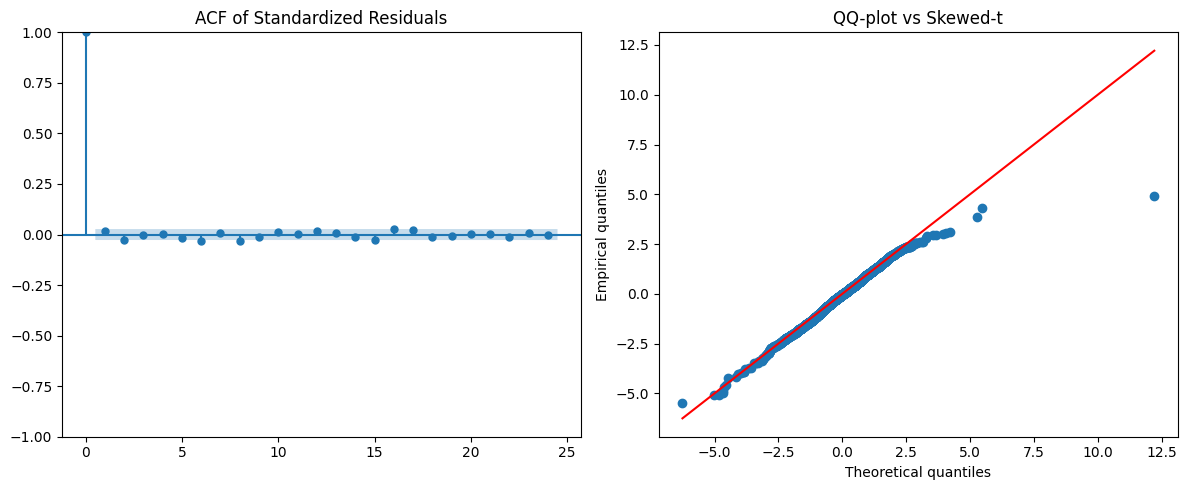

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: ACF of standardized residuals
plot_acf(z_garch, lags=24, ax=axes[0])
axes[0].set_title("ACF of Standardized Residuals")

# Right plot: QQ plot

from arch.univariate.distribution import SkewStudent

dist = SkewStudent()

# simulate same size as data
eta = res_garch.params['eta']
lamb = res_garch.params['lambda']

simulated = dist.simulate([eta, lamb])(len(z_garch))

# sort both
empirical = np.sort(z_garch)
theoretical = np.sort(simulated)

axes[1].scatter(theoretical, empirical)
axes[1].plot(theoretical, theoretical, color='red')  # 45-degree line
axes[1].set_title("QQ-plot vs Skewed-t")
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Empirical quantiles")

plt.tight_layout()
plt.show()

### Out-of-sample Forecast

In [ ]:
# Rolling window forecasting
results_garch= []
window = 750

for t in range(train_end, len(returns.iloc[:val_end])):

    # Rolling window:
    train_window = returns.iloc[t - window:t]

    # Get the index label of the target observation we are forecasting for
    target_index = returns.index[t]

    model = arch_model(
        train_window,
        mean    = "ARX",
        lags    = 1,
        vol     = "GARCH",
        p       = 1,
        q       = 1,
        dist    = "skewt")

    result = model.fit(disp='off', show_warning=False)

    try:
        params = result.params
        se = result.std_err
        cov = result.param_cov

        required_keys = ['alpha[1]', 'beta[1]']

        if not all(k in params and k in se and not np.isnan(se[k]) for k in required_keys):
            continue

        omega = params['omega']
        alpha = params['alpha[1]']
        beta  = params['beta[1]']
        eta   = params['eta']
        lamb  = params['lambda']

        alpha_se = se['alpha[1]']
        beta_se  = se['beta[1]']
        eta_se   = se['eta']
        lamb_se  = se['lambda']

        cov_ab = cov.loc['alpha[1]', 'beta[1]']
        if np.isnan(cov_ab):
            continue
        valid = (
        (omega > 0) and
        (alpha >= 0) and
        (beta >= 0) and
        (alpha + beta < 1) and
        (eta > 2) and
        (lamb < 1) and
        (lamb > -1) and
        np.isfinite(result.params).all() and
        result.convergence_flag == 0
        )

        if not valid:
          continue

        forecast = result.forecast(horizon=1)
        sigma2 = forecast.variance.iloc[-1, 0]
        sigma = np.sqrt(sigma2)

        if np.isnan(sigma):
            continue

        # Append the original index alongside the metrics
        results_garch.append({
            "target_date": target_index,
            "volatility": sigma,
            "persistence": alpha + beta,
            "persistence_se" : np.sqrt(alpha_se**2 + beta_se**2 + 2 * cov_ab),
            "eta": eta,
            "eta_se": eta_se,
            "lamb": lamb,
            "lamb_se": lamb_se
        })

    except (KeyError, ValueError, AttributeError):
        continue

# Convert the results into a clean DataFrame using the original index structure
df_results_garch = pd.DataFrame(results_garch)
if not df_results_garch.empty:
    df_results_garch.set_index("target_date", inplace=True)

In [ ]:
df_results_garch.head()

,volatility,persistence,persistence_se,eta,eta_se,lamb,lamb_se
target_date,,,,,,,
2020-10-15,1.668363,0.985639,0.018569,5.927197,1.214699,-0.225569,0.049617
2020-10-16,1.570910,0.984802,0.018497,6.056880,1.248991,-0.226016,0.049380
2020-10-19,1.455543,0.984219,0.018528,6.101767,1.263103,-0.226199,0.049114
2020-10-20,1.576821,0.984258,0.018411,6.230640,1.312596,-0.228970,0.048252
2020-10-21,1.441767,0.984829,0.018041,6.551595,1.489864,-0.243481,0.048312


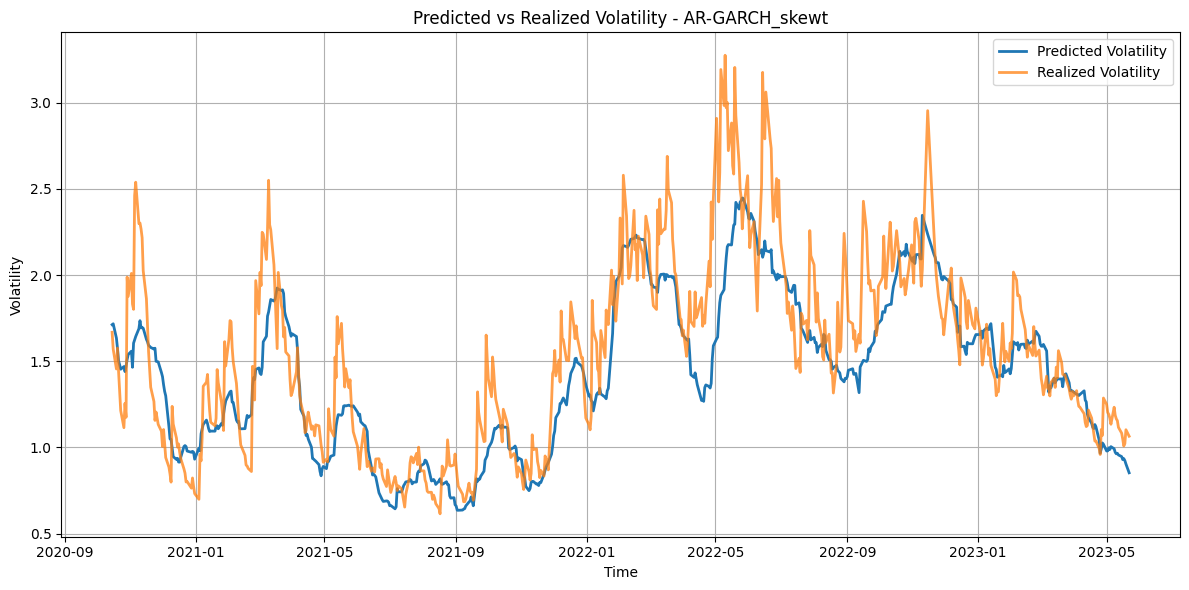

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_results_garch.index, rv_val.loc[df_results_garch.index], label='Predicted Volatility', linewidth=2)
plt.plot(df_results_garch.index, df_results_garch['volatility'], label='Realized Volatility', alpha=0.75, linewidth=2)

plt.title('Predicted vs Realized Volatility - AR-GARCH_skewt')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

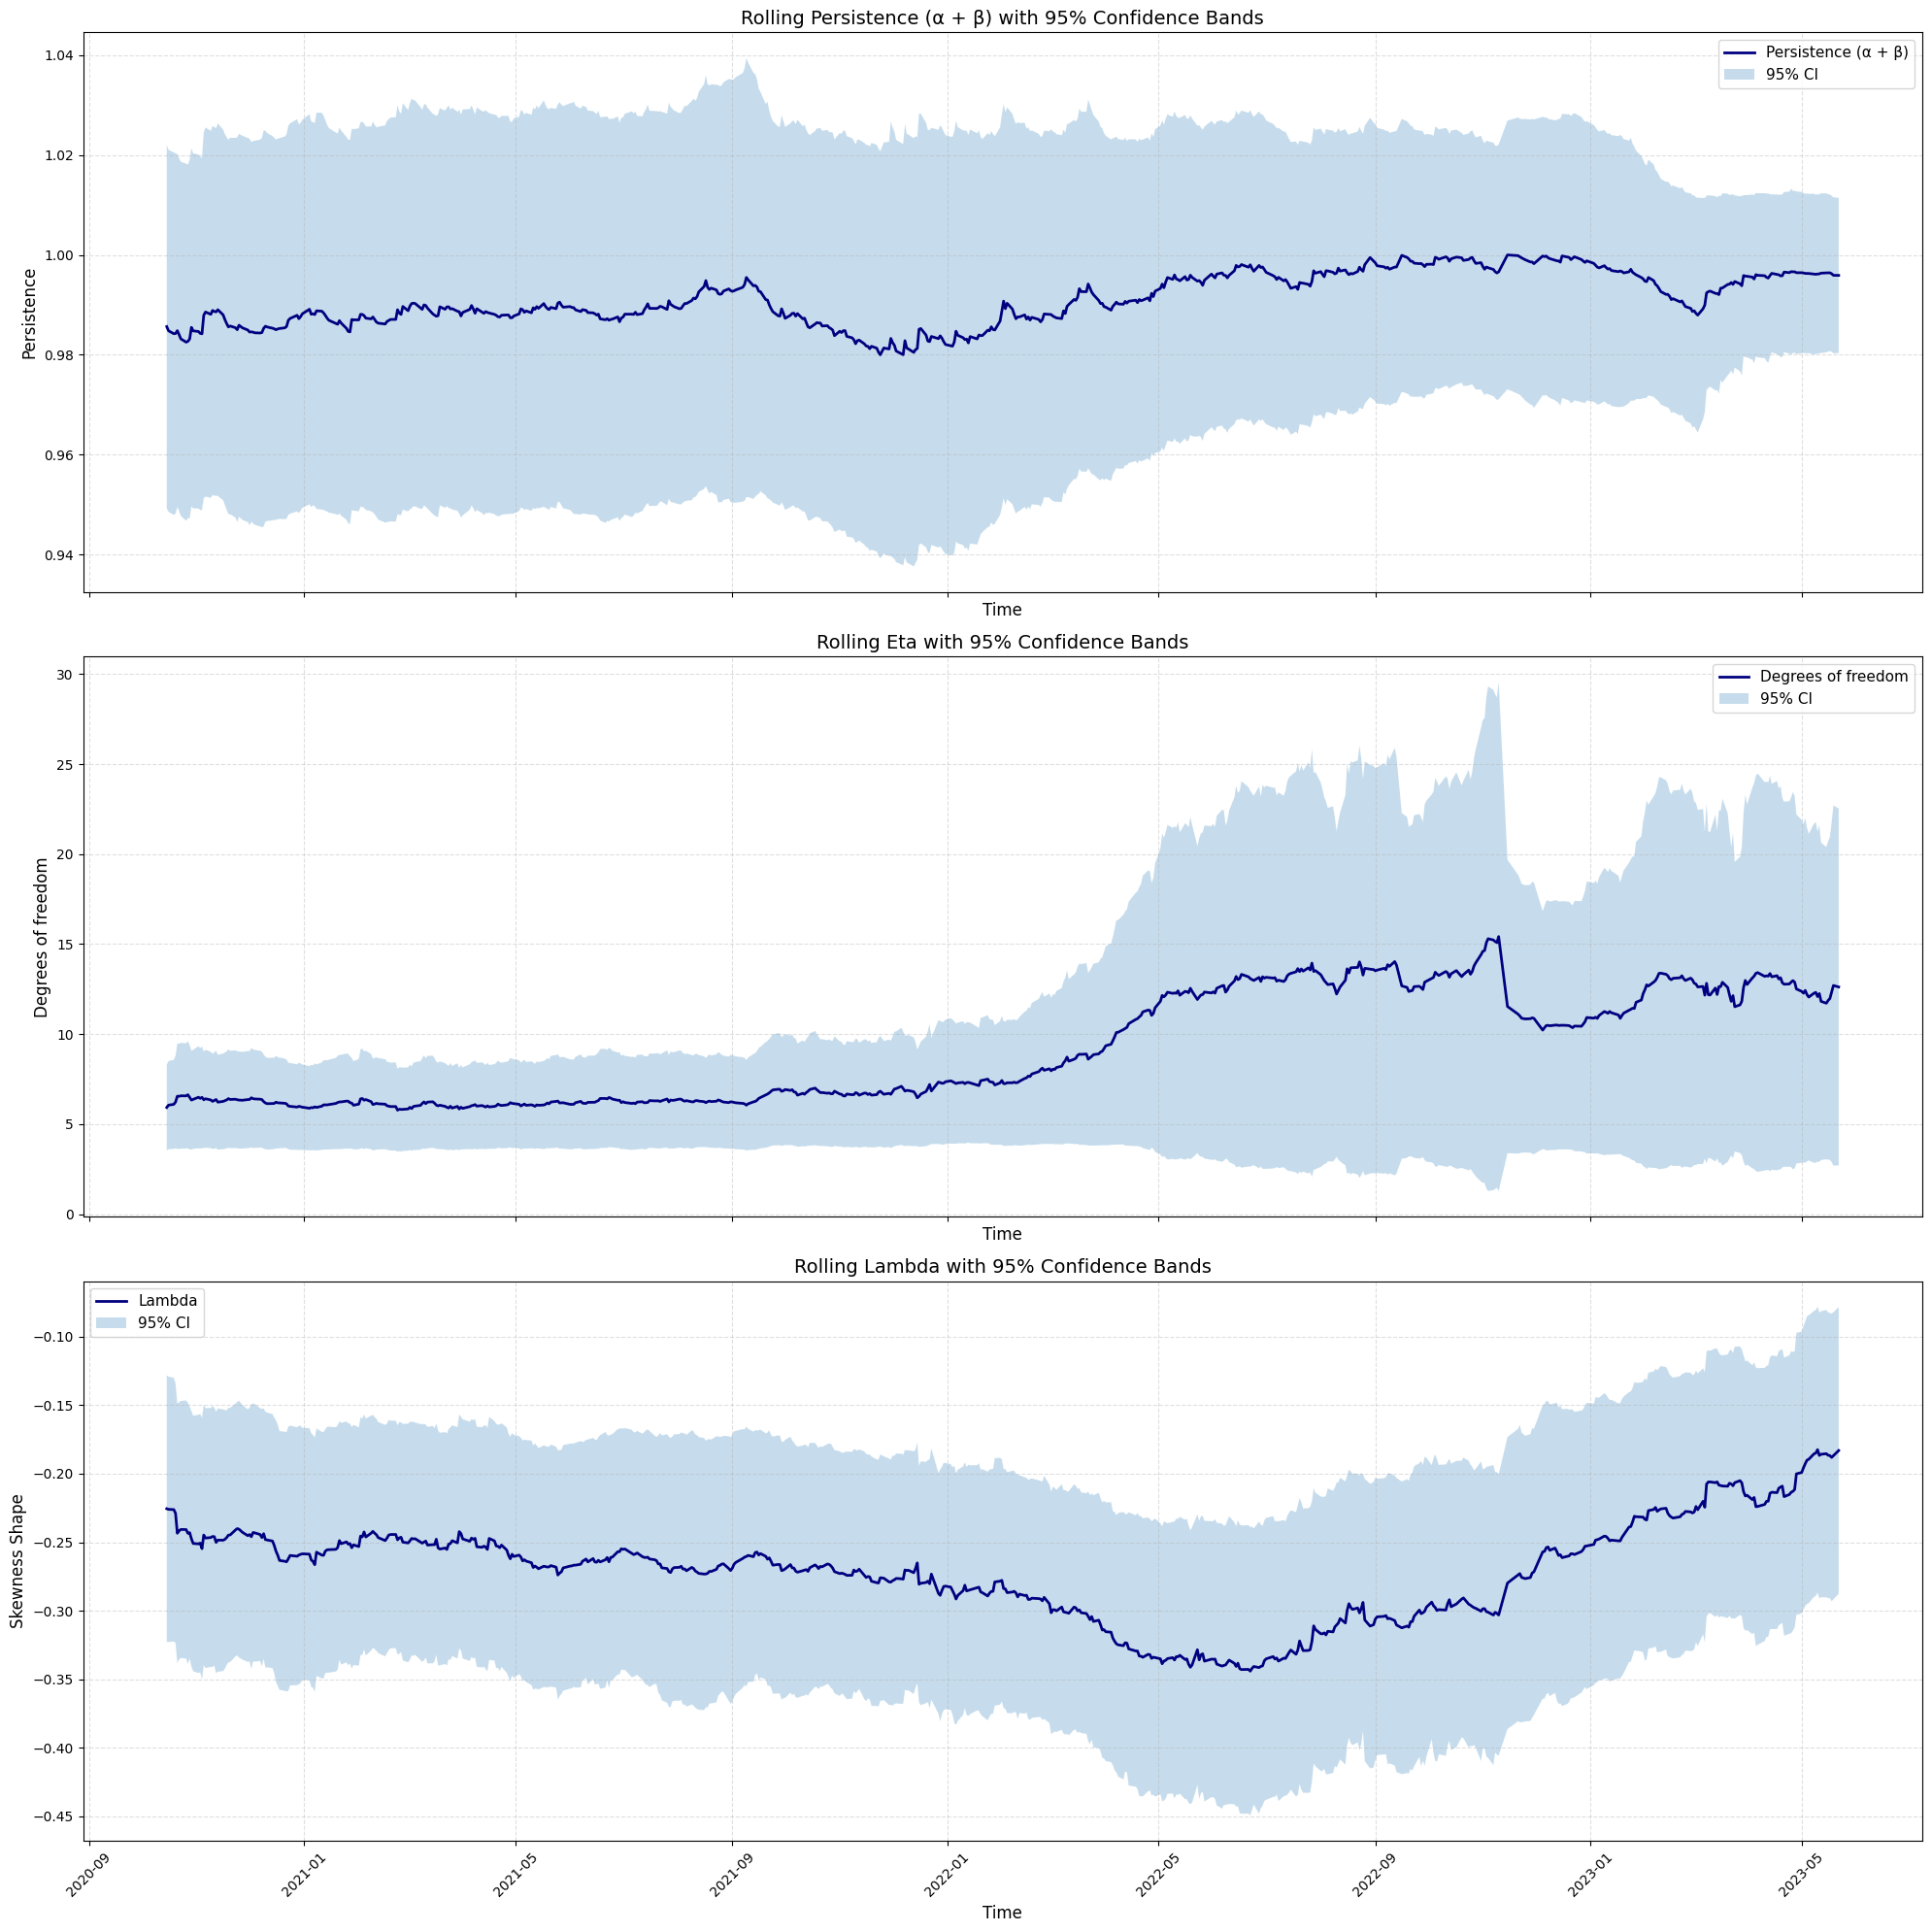

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20), sharex=True)

# 1. Persistence
persistence = df_results_garch['persistence']
persistence_se = df_results_garch['persistence_se']

persistence_upper = persistence + 1.96 * persistence_se
persistence_lower = persistence - 1.96 * persistence_se

axes[0].plot(df_results_garch.index, persistence, label="Persistence (α + β)", linewidth=2, color="navy")
axes[0].fill_between(df_results_garch.index, persistence_lower, persistence_upper, alpha=0.25, label="95% CI")

axes[0].set_title("Rolling Persistence (α + β) with 95% Confidence Bands", fontsize=14)
axes[0].set_ylabel("Persistence", fontsize=12)
axes[0].set_xlabel("Date", fontsize=12)

# 2. Eta
eta = df_results_garch['eta']
eta_se = df_results_garch['eta_se']

eta_upper = eta + 1.96 * eta_se
eta_lower = eta - 1.96 * eta_se

axes[1].plot(df_results_garch.index, eta, label="Degrees of freedom", linewidth=2, color="navy")
axes[1].fill_between(df_results_garch.index, eta_lower, eta_upper, alpha=0.25, label="95% CI")

axes[1].set_title("Rolling Eta with 95% Confidence Bands", fontsize=14)
axes[1].set_ylabel("Degrees of freedom", fontsize=12)
axes[1].set_xlabel("Date", fontsize=12)

# 3. Lambda
lamb = df_results_garch['lamb']
lamb_se = df_results_garch['lamb_se']

lamb_upper = lamb + 1.96 * lamb_se
lamb_lower = lamb - 1.96 * lamb_se

axes[2].plot(df_results_garch.index, lamb, label="Lambda", linewidth=2, color="navy")
axes[2].fill_between(df_results_garch.index, lamb_lower, lamb_upper, alpha=0.25, label="95% CI")

axes[2].set_title("Rolling Lambda with 95% Confidence Bands", fontsize=14)
axes[2].set_ylabel("Skewness Shape", fontsize=12)
axes[2].set_xlabel("Date", fontsize=12)


for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.set_xlabel("Time")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

## EGARCH

### In-sample Estimation

In [ ]:
# Fit model on training data
egarch = arch_model(
    train,
    vol     = "EGARCH",
    p       = 1,
    o       = 1,
    q       = 1
)

res_egarch = egarch.fit(disp='off')

print(res_egarch.summary())

# Extract standardized residuals
z_egarch = res_egarch.resid / res_egarch.conditional_volatility

                     Constant Mean - EGARCH Model Results                     
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -8812.14
Distribution:                  Normal   AIC:                           17634.3
Method:            Maximum Likelihood   BIC:                           17667.1
                                        No. Observations:                 5229
Date:                Tue, Sep 08 2026   Df Residuals:                     5228
Time:                        18:56:33   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0372  1.537e-02      2.422  1.545e-02 [7.

In [ ]:
# Ljung-Box test for standardized residuals
lb_resid = acorr_ljungbox(z_egarch, lags=[10, 15, 20], return_df=True)
print(lb_resid)

      lb_stat  lb_pvalue
10  22.428525   0.013064
15  29.220952   0.015062
20  39.528195   0.005728


In [ ]:
# Ljung-Box test for standardized residuals
lb_resid = acorr_ljungbox(z_egarch**2, lags=[10, 15, 20], return_df=True)
print(lb_resid)

      lb_stat  lb_pvalue
10  12.493210   0.253402
15  16.196472   0.369116
20  35.189830   0.019116


In [ ]:
# ARCH effect test
arch_test_results = het_arch(z_egarch, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")
print(f"F-statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

LM Statistic: 5.854
p-value: 0.321
F-statistic: 1.171
F p-value: 0.321


In [ ]:
# Basic statistics
print("Basic statistics:")
print(z_egarch.describe())
print("\nSkewness:", stats.skew(z_egarch.dropna()))
print("Kurtosis:", stats.kurtosis(z_egarch.dropna()))

Basic statistics:
count    5229.000000
mean       -0.007194
std         1.000277
min        -6.063072
25%        -0.565028
50%         0.054606
75%         0.616058
max         4.337387
dtype: float64

Skewness: -0.46825133785905576
Kurtosis: 1.4205120070697674


In [ ]:
# Jarque-Bera test
jb_stat, jb_pvalue = jarque_bera(z_egarch)
print("JB p-value:", jb_pvalue)

JB p-value: 1.0962567985315166e-137


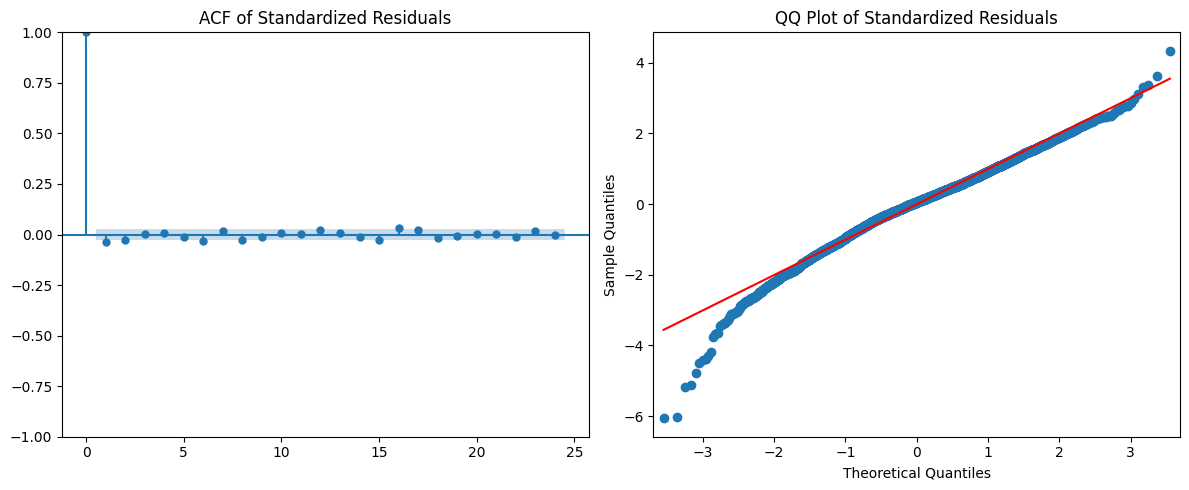

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: ACF of standardized residuals
plot_acf(z_egarch, lags=24, ax=axes[0])
axes[0].set_title("ACF of Standardized Residuals")

# Right plot: QQ plot
sm.qqplot(z_egarch, line='s', ax=axes[1])
axes[1].set_title("QQ Plot of Standardized Residuals")

plt.tight_layout()
plt.show()

### Out-of-sample Forecast

In [ ]:
# Rolling window forecasting
results_egarch = []
window = 1000

for t in range(train_end, len(returns.iloc[:val_end])):

    # Rolling window: fixed block of 1000 observations
    train_window = returns.iloc[t - window:t]

    # Get the index label of the target observation we are forecasting for
    target_index = returns.index[t]

    model = arch_model(
        train_window,
        vol     = "EGARCH",
        p       = 1,
        o       = 1,
        q       = 1
    )

    result = model.fit(disp='off', show_warning=False)

    try:
        params = result.params
        se = result.std_err
        cov = result.param_cov

        required_keys = ['alpha[1]', 'beta[1]', 'gamma[1]']

        if not all(k in params and k in se and not np.isnan(se[k]) for k in required_keys):
            continue

        beta  = params['beta[1]']
        gamma = params['gamma[1]']

        gamma_se = se['gamma[1]']
        beta_se  = se['beta[1]']

        valid = (
            (abs(beta) < 1) and
            np.isfinite(result.params).all() and
            result.convergence_flag == 0
        )

        if not valid:
          continue

        forecast = result.forecast(horizon=1)
        sigma2 = forecast.variance.iloc[-1, 0]
        sigma = np.sqrt(sigma2)

        if np.isnan(sigma):
            continue

        # Append the original index alongside the metrics
        results_egarch.append({
            "target_date": target_index,
            "volatility": sigma,
            "beta" : beta,
            "beta_se" : beta_se,
            "gamma" : gamma,
            "gamma_se" : gamma_se,
        })

    except (KeyError, ValueError, AttributeError):
        continue

# Convert the results into a clean DataFrame using the original index structure
df_results_egarch = pd.DataFrame(results_egarch)
if not df_results_egarch.empty:
    df_results_egarch.set_index("target_date", inplace=True)

In [ ]:
df_results_egarch.head()

,volatility,beta,beta_se,gamma,gamma_se
target_date,,,,,
2020-10-15,1.498934,0.952526,0.013792,-0.105041,0.037944
2020-10-16,1.478881,0.952302,0.013827,-0.105410,0.038027
2020-10-19,1.402850,0.952045,0.013875,-0.105939,0.038092
2020-10-20,1.621818,0.952285,0.013827,-0.106058,0.038153
2020-10-21,1.468002,0.952155,0.013825,-0.106079,0.038203


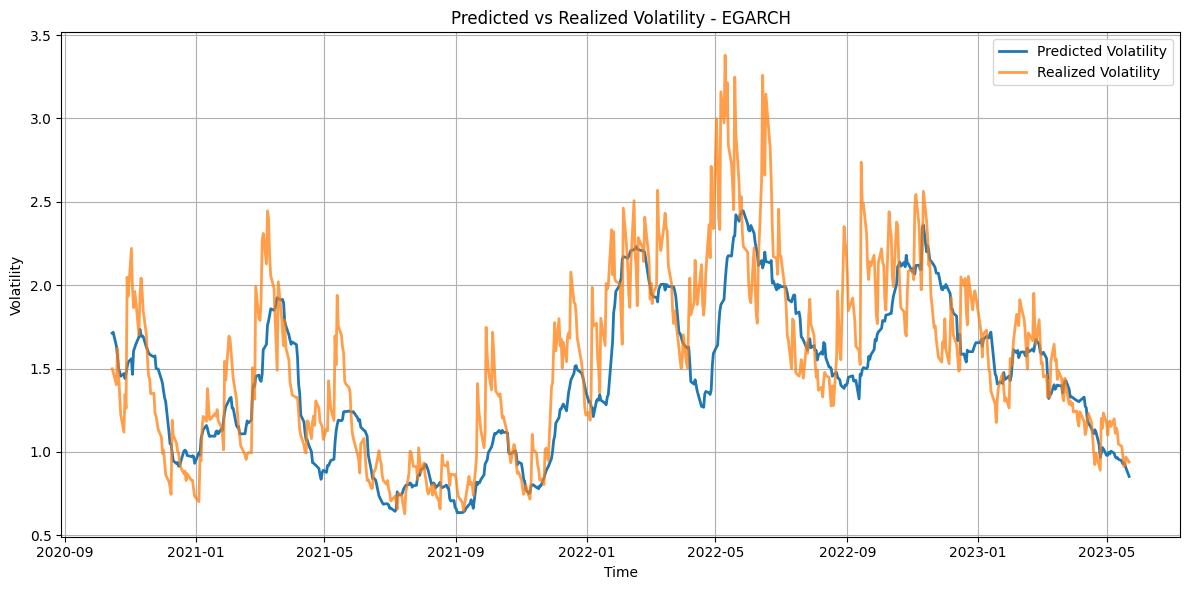

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_results_egarch.index, rv_val.loc[df_results_egarch.index], label='Predicted Volatility', linewidth=2)
plt.plot(df_results_egarch.index, df_results_egarch['volatility'], label='Realized Volatility', alpha=0.75, linewidth=2)

plt.title('Predicted vs Realized Volatility - EGARCH')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## GJR-GARCH

### In-sample Estimation

In [ ]:
# Fit model on training data
gjr = arch_model(
    train,
    vol     = "GARCH",
    p       = 1,
    o       = 1,
    q       = 1
)

res_gjr = gjr.fit(disp='off')

print(res_gjr.summary())

# Extract standardized residuals
z_gjr = res_gjr.resid / res_gjr.conditional_volatility

                   Constant Mean - GJR-GARCH Model Results                    
Dep. Variable:                Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                  GJR-GARCH   Log-Likelihood:               -8809.42
Distribution:                  Normal   AIC:                           17628.8
Method:            Maximum Likelihood   BIC:                           17661.7
                                        No. Observations:                 5229
Date:                Tue, Sep 08 2026   Df Residuals:                     5228
Time:                        18:59:53   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0412  1.526e-02      2.696  7.013e-03 [1.

In [ ]:
# Ljung-Box test for standardized residuals
lb_resid = acorr_ljungbox(z_gjr, lags=[10, 15, 20], return_df=True)
print(lb_resid)

      lb_stat  lb_pvalue
10  19.496039   0.034396
15  26.232717   0.035647
20  34.793292   0.021233


In [ ]:
# Ljung-Box test for standardized residuals
lb_resid = acorr_ljungbox(z_gjr**2, lags=[10, 15, 20], return_df=True)
print(lb_resid)

      lb_stat  lb_pvalue
10  12.268904   0.267463
15  17.819436   0.272277
20  24.915863   0.204669


In [ ]:
# ARCH effect test
arch_test_results = het_arch(z_gjr, nlags=5)

print(f"LM Statistic: {arch_test_results[0]:.3f}")
print(f"p-value: {arch_test_results[1]:.3f}")
print(f"F-statistic: {arch_test_results[2]:.3f}")
print(f"F p-value: {arch_test_results[3]:.3f}")

LM Statistic: 5.940
p-value: 0.312
F-statistic: 1.188
F p-value: 0.312


In [ ]:
# Basic statistics
print("Basic statistics:")
print(z_gjr.describe())
print("\nSkewness:", stats.skew(z_gjr.dropna()))
print("Kurtosis:", stats.kurtosis(z_gjr.dropna()))

Basic statistics:
count    5229.000000
mean       -0.009046
std         1.000178
min        -6.216885
25%        -0.573418
50%         0.049574
75%         0.608693
max         4.168305
dtype: float64

Skewness: -0.4191286553908219
Kurtosis: 1.2431423093652736


In [ ]:
# Jarque-Bera test
jb_stat, jb_pvalue = jarque_bera(z_gjr)
print("JB p-value:", jb_pvalue)

JB p-value: 4.378011859063944e-107


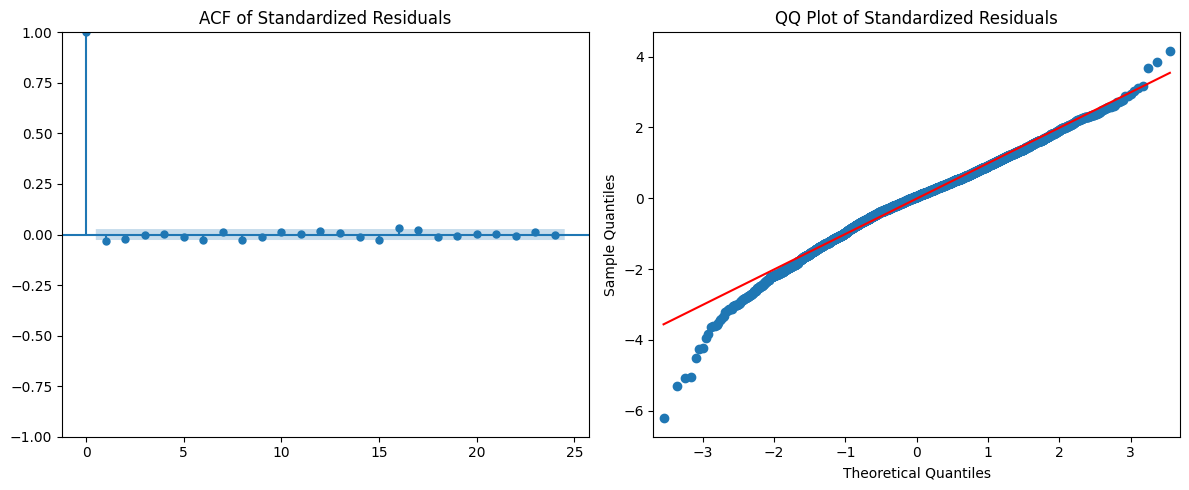

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: ACF of standardized residuals
plot_acf(z_gjr, lags=24, ax=axes[0])
axes[0].set_title("ACF of Standardized Residuals")

# Right plot: QQ plot
sm.qqplot(z_gjr, line='s', ax=axes[1])
axes[1].set_title("QQ Plot of Standardized Residuals")

plt.tight_layout()
plt.show()

### Out-of-sample Forecast

In [ ]:
# Rolling window forecasting
results_gjr = []
window = 1000

for t in range(train_end, len(returns.iloc[:val_end])):

    # Rolling window: fixed block of 1000 observations
    train_window = returns.iloc[t - window:t]

    # Get the index label of the target observation we are forecasting for
    target_index = returns.index[t]

    model = arch_model(
        train_window,
        vol     = "GARCH",
        p       = 1,
        o       = 1,
        q       = 1
    )

    result = model.fit(disp='off', show_warning=False)

    try:
        params = result.params
        se = result.std_err
        cov = result.param_cov

        required_keys = ['alpha[1]', 'beta[1]', 'gamma[1]']

        if not all(k in params and k in se and not np.isnan(se[k]) for k in required_keys):
            continue

        omega = params['omega']
        alpha = params['alpha[1]']
        beta  = params['beta[1]']
        gamma = params['gamma[1]']

        alpha_se = se['alpha[1]']
        gamma_se = se['gamma[1]']
        beta_se  = se['beta[1]']

        valid = (
        (omega > 0) and
        (alpha >= 0) and
        (beta >= 0) and
        (alpha + gamma >= 0) and
        (alpha + gamma/2 + beta < 1) and
        np.isfinite(result.params).all() and
        result.convergence_flag == 0
        )

        if not valid:
          continue

        forecast = result.forecast(horizon=1)
        sigma2 = forecast.variance.iloc[-1, 0]
        sigma = np.sqrt(sigma2)

        if np.isnan(sigma):
            continue

        # Covariance
        cov_ab = cov.loc['alpha[1]', 'beta[1]']
        cov_bc = cov.loc['alpha[1]', 'gamma[1]']
        cov_ac = cov.loc['beta[1]', 'gamma[1]']


        # Append the original index alongside the metrics
        results_gjr.append({
            "target_date": target_index,
            "volatility": sigma,
            "persistence": alpha + gamma/2 + beta,
            "persistence_se": np.sqrt(alpha_se**2 + beta_se**2 + 1/4 * gamma_se**2 + 2 * cov_ab + cov_ac + cov_bc),
            "gamma": gamma,
            "gamma_se": gamma_se
        })

    except (KeyError, ValueError, AttributeError):
        continue

# Convert the results into a clean DataFrame using the original index structure
df_results_gjr = pd.DataFrame(results_gjr)
if not df_results_gjr.empty:
    df_results_gjr.set_index("target_date", inplace=True)

In [ ]:
df_results_gjr.head()

,volatility,persistence,persistence_se,gamma,gamma_se
target_date,,,,,
2020-10-15,1.475405,0.967517,0.021136,0.140630,0.074080
2020-10-16,1.395487,0.967138,0.021124,0.140928,0.074214
2020-10-19,1.287911,0.966718,0.021180,0.141643,0.074428
2020-10-20,1.515067,0.967325,0.020992,0.140600,0.074357
2020-10-21,1.375894,0.966918,0.020974,0.139894,0.074270


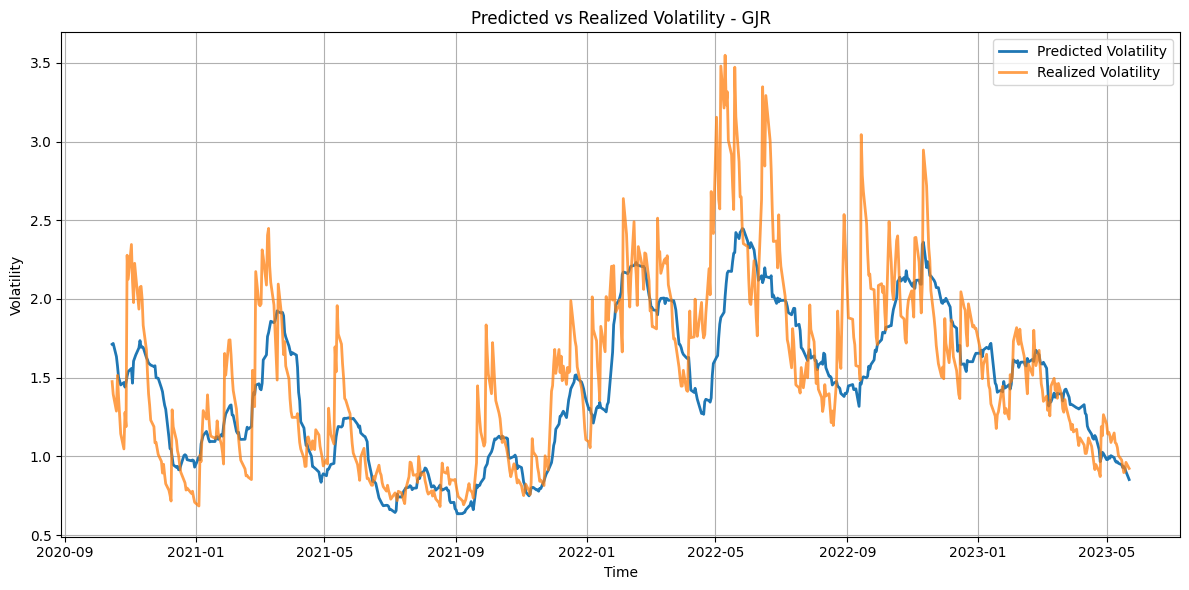

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_results_gjr.index, rv_val.loc[df_results_gjr.index], label='Predicted Volatility', linewidth=2)
plt.plot(df_results_gjr.index, df_results_gjr['volatility'], label='Realized Volatility', alpha=0.75,linewidth=2)

plt.title('Predicted vs Realized Volatility - GJR')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()